# TP Optimisation — Exercice 3 : clustering par optimisation des centroïdes




In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.1.3 | pandas 2.2.3


In [2]:
QUICK = False
SEEDS = [42, 123, 2024]

FILES = {
    "blobs":   "clustering_blobs3.csv",
    "wine":    "clustering_wine.csv",
    "fashion": "fashion_mnist_50k_10k_10k.npz",
    "mnist":   "mnist_50k_10k_10k.npz",
}
RUN_CSV    = ["blobs", "wine"]
RUN_IMAGES = ["fashion", "mnist"]

K_BY_DATASET   = {"blobs": 3, "wine": 3, "fashion": 10, "mnist": 10}
TAU_BY_DATASET = {"blobs": 0.25, "wine": 0.25, "fashion": 5.0, "mnist": 5.0}
ETA_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]


CFG_CSV = {"epochs_full": 100, "epochs_mb": 50, "batch_size": 64,   "lloyd_iters": 30}
CFG_IMG = {"epochs_full": 15 if QUICK else 40, "epochs_mb": 8, "batch_size": 2048, "lloyd_iters": 20}
QUICK_N = (5000, 1000, 1000)

METHODS = ["gd", "gd+ls", "sgd", "momentum", "adagrad", "rmsprop", "adam"]
ALL_NAMES = METHODS + ["lloyd"]
COLORS = {m: plt.cm.tab10(i) for i, m in enumerate(ALL_NAMES)}

OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)

In [3]:

from sklearn.datasets import load_wine

wine_path = Path("data") / "clustering_wine.csv"
wine_path.parent.mkdir(exist_ok=True)

if not wine_path.exists() and not Path("clustering_wine.csv").exists():
    wine = load_wine(as_frame=True)
    df_wine = wine.data.copy()
    df_wine["true_label"] = wine.target
    df_wine.to_csv(wine_path, index=False)
    print(f"Créé : {wine_path} -> {df_wine.shape}")
else:
    print("clustering_wine.csv déjà présent")

Créé : data/clustering_wine.csv -> (178, 14)


In [4]:

LABEL_CANDIDATES = ("true_label", "label", "target", "class", "y")

def locate(filename: str):
    for p in (Path(filename), Path("data") / filename):
        if p.exists():
            return p
    return None


def load_tabular_all(key: str):
    p = locate(FILES[key])
    if p is None:
        raise FileNotFoundError(f"Dataset introuvable pour {key}: {FILES[key]} (recherché racine et data/)")
    df = pd.read_csv(p)
    lab = next((c for c in LABEL_CANDIDATES if c in df.columns), None)
    if lab is None:
        raise ValueError(f"Aucune colonne label trouvée dans {p}. Colonnes: {list(df.columns)}")
    feat_cols = [c for c in df.columns if c not in {lab, "split"} and not str(c).startswith("Unnamed")]
    X = df[feat_cols].to_numpy(dtype=np.float64)
    y = pd.factorize(df[lab], sort=True)[0].astype(int)
    mu, sd = X.mean(axis=0), X.std(axis=0)
    X = (X - mu) / np.where(sd > 0, sd, 1.0)
    print(f"{key}: n={X.shape[0]}, d={X.shape[1]}, classes de référence={len(np.unique(y))}")
    return X, y


def ensure_npz(key: str):
    p = locate(FILES[key])
    if p is not None:
        return p
    print(f"{FILES[key]} absent -> tentative de reconstruction via tensorflow.keras.datasets ...")
    try:
        if key == "fashion":
            from tensorflow.keras.datasets import fashion_mnist as ds
        else:
            from tensorflow.keras.datasets import mnist as ds
        (xa, ya), (xt, yt) = ds.load_data()
        path = Path("data") / FILES[key]
        path.parent.mkdir(exist_ok=True)
        np.savez_compressed(path, x_train=xa[:50000], y_train=ya[:50000],
                            x_val=xa[50000:], y_val=ya[50000:], x_test=xt, y_test=yt)
        print("NPZ reconstruit :", path)
        return path
    except Exception as ex:
        print(f"Impossible d'obtenir {FILES[key]} ({type(ex).__name__}: {ex}). Jeu ignoré.")
        return None


def load_images_npz(key: str):
    p = ensure_npz(key)
    if p is None:
        return None
    z = np.load(p)
    def prep(k):
        a = z[k]
        return a.reshape(len(a), -1).astype(np.float32) / 255.0      # 784 pixels dans [0, 1]
    out = {"train": prep("x_train"), "val": prep("x_val"), "test": prep("x_test"),
           "y_train": z["y_train"].astype(int), "y_val": z["y_val"].astype(int), "y_test": z["y_test"].astype(int)}
    if QUICK:
        for part, n in zip(["train", "val", "test"], QUICK_N):
            out[part] = out[part][:n]
            out["y_" + part] = out["y_" + part][:n]
    print(f"{key}: train={out['train'].shape}, val={out['val'].shape}, test={out['test'].shape}, "
          f"pixels in [{out['train'].min():.2f}, {out['train'].max():.2f}]"
          + (" | QUICK (sous-échantillon)" if QUICK else ""))
    return out

In [5]:

CALLS = {"grad": 0, "loss": 0}

def sqdist(X, C):

    x2 = np.sum(X * X, axis=1, keepdims=True)
    c2 = np.sum(C * C, axis=1, keepdims=True).T
    return np.maximum(x2 + c2 - 2.0 * (X @ C.T), 0.0)


def softmin_loss(X, C, tau, count=True):
    if count:
        CALLS["loss"] += 1
    D = sqdist(X, C)
    m = D.min(axis=1, keepdims=True)
    S = np.exp(-(D - m) / tau).sum(axis=1)
    return float(np.mean(m[:, 0] - tau * np.log(S)) + tau * np.log(C.shape[0]))


def softmin_loss_and_grad(X, C, tau):
    CALLS["grad"] += 1
    D = sqdist(X, C)
    m = D.min(axis=1, keepdims=True)
    Z = np.exp(-(D - m) / tau)
    S = Z.sum(axis=1, keepdims=True)
    Q = Z / S
    loss = float(np.mean(m[:, 0] - tau * np.log(S[:, 0])) + tau * np.log(C.shape[0]))
    n = X.shape[0]
    grad = (2.0 / n) * (Q.sum(axis=0)[:, None] * C - Q.T @ X)
    return loss, grad

In [6]:

def gradient_check(seed=42, h=1e-5, n_coords=8, tau=0.7):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(40, 5)); C = rng.normal(size=(3, 5)); K = C.shape[0]

    L, G = softmin_loss_and_grad(X, C, tau)


    D = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    L_naive = -tau * np.mean(np.log(np.mean(np.exp(-D / tau), axis=1)))
    Q = np.exp(-D / tau); Q /= Q.sum(axis=1, keepdims=True)
    G_naive = (2.0 / len(X)) * (np.diag(Q.sum(axis=0)) @ C - Q.T @ X)
    print(f"[analytique] |J - J_naif| = {abs(L - L_naive):.2e} | max|G - G_naif| = {np.abs(G - G_naive).max():.2e}")


    coords = [(int(rng.integers(K)), int(rng.integers(C.shape[1]))) for _ in range(n_coords)]
    rels = []
    for k, j in coords:
        E = np.zeros_like(C); E[k, j] = h
        gn = (softmin_loss(X, C + E, tau, count=False) - softmin_loss(X, C - E, tau, count=False)) / (2 * h)
        rels.append(abs(gn - G[k, j]) / max(abs(gn) + abs(G[k, j]), 1e-12))
    print(f"[numérique, h={h:g}] erreur relative max = {max(rels):.2e} | moyenne = {np.mean(rels):.2e}")

gradient_check()

[analytique] |J - J_naif| = 8.88e-16 | max|G - G_naif| = 4.44e-16
[numérique, h=1e-05] erreur relative max = 2.54e-10 | moyenne = 8.66e-11


In [7]:

def assign_labels(X, C):
    return np.argmin(sqdist(X, C), axis=1)


def init_centroids(X, K, seed):

    rng = np.random.default_rng(seed)
    for _ in range(50):
        idx = rng.choice(len(X), size=K, replace=False)
        if len(np.unique(X[idx], axis=0)) == K:
            break
    return X[idx].copy()


def make_batches(n, batch_size, rng):
    idx = np.arange(n)
    rng.shuffle(idx)
    for s in range(0, n, batch_size):
        yield idx[s:s + batch_size]


def golden_step(X, C, G, tau, eta_max, n_iter=12):

    phi = (np.sqrt(5.0) - 1.0) / 2.0
    f = lambda s: softmin_loss(X, C - s * G, tau)
    a, b = 0.0, float(eta_max)
    c = b - phi * (b - a); d = a + phi * (b - a)
    fc, fd = f(c), f(d)
    for _ in range(n_iter):
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - phi * (b - a); fc = f(c)
        else:
            a, c, fc = c, d, fd
            d = a + phi * (b - a); fd = f(d)
    return float((a + b) / 2.0)


def run_optimizer(method, Xtr, Xva, K, tau, eta, seed, epochs, batch_size=256):
    rng = np.random.default_rng(seed)
    C = init_centroids(Xtr, K, seed)

    v = np.zeros_like(C); s = np.zeros_like(C); m = np.zeros_like(C)
    mu = rho = beta1 = 0.9
    beta2, eps = 0.999, 1e-8

    t = 0
    g0, l0 = CALLS["grad"], CALLS["loss"]
    t_train = 0.0
    best_val, best_C, best_epoch = np.inf, C.copy(), 0
    hist = {"epoch": [], "train_loss": [], "val_loss": [], "time": []}

    for e in range(1, epochs + 1):
        t0 = time.perf_counter()
        if method in {"gd", "gd+ls"}:
            _, G = softmin_loss_and_grad(Xtr, C, tau)
            step = eta if method == "gd" else golden_step(Xtr, C, G, tau, eta)
            C = C - float(step) * G
            t += 1
        else:
            for ib in make_batches(len(Xtr), batch_size, rng):
                _, G = softmin_loss_and_grad(Xtr[ib], C, tau)
                t += 1
                if method == "sgd":
                    C -= eta * G
                elif method == "momentum":
                    v = mu * v + G
                    C -= eta * v
                elif method == "adagrad":
                    s += G * G
                    C -= eta * G / (np.sqrt(s) + eps)
                elif method == "rmsprop":
                    s = rho * s + (1 - rho) * (G * G)
                    C -= eta * G / (np.sqrt(s) + eps)
                elif method == "adam":
                    m = beta1 * m + (1 - beta1) * G
                    s = beta2 * s + (1 - beta2) * (G * G)
                    mh = m / (1 - beta1 ** t)
                    sh = s / (1 - beta2 ** t)
                    C -= eta * mh / (np.sqrt(sh) + eps)
                else:
                    raise ValueError(f"Méthode inconnue: {method}")
        t_train += time.perf_counter() - t0

        Ltr = softmin_loss(Xtr, C, tau, count=False)
        Lva = softmin_loss(Xva, C, tau, count=False)
        hist["epoch"].append(e); hist["train_loss"].append(Ltr)
        hist["val_loss"].append(Lva); hist["time"].append(t_train)
        if np.isfinite(Lva) and Lva < best_val:            # meilleure époque = min de la perte de validation
            best_val, best_C, best_epoch = Lva, C.copy(), e

    info = {"best_epoch": best_epoch, "n_updates": t, "n_grad": CALLS["grad"] - g0,
            "n_loss": CALLS["loss"] - l0, "train_time_s": t_train, "best_val_loss": best_val}
    return best_C, hist, info


def run_lloyd(Xtr, Xva, K, tau, seed, n_iters):
    C = init_centroids(Xtr, K, seed)
    t_train = 0.0
    hist = {"epoch": [], "train_loss": [], "val_loss": [], "time": []}
    for e in range(1, n_iters + 1):
        t0 = time.perf_counter()
        lab = assign_labels(Xtr, C)
        for j in range(K):
            mk = lab == j
            if np.any(mk):
                C[j] = Xtr[mk].mean(axis=0)
        t_train += time.perf_counter() - t0
        hist["epoch"].append(e)
        hist["train_loss"].append(softmin_loss(Xtr, C, tau, count=False))
        hist["val_loss"].append(softmin_loss(Xva, C, tau, count=False))
        hist["time"].append(t_train)
    info = {"best_epoch": n_iters, "n_updates": n_iters, "n_grad": 0, "n_loss": 0,
            "train_time_s": t_train, "best_val_loss": hist["val_loss"][-1]}
    return C, hist, info

In [8]:

def eval_clustering(X, y_true, C, tau, sil_idx):
    D = sqdist(X, C)
    y_pred = D.argmin(axis=1)
    out = {
        "J_tau": softmin_loss(X, C, tau, count=False),
        "inertia_mean": float(D.min(axis=1).mean()),
        "n_clusters": int(len(np.unique(y_pred))),
        "ari": float(adjusted_rand_score(y_true, y_pred)),
        "nmi": float(normalized_mutual_info_score(y_true, y_pred)),
    }
    ys = y_pred[sil_idx]
    out["silhouette"] = float(silhouette_score(X[sil_idx], ys)) if len(np.unique(ys)) > 1 else np.nan
    return out, y_pred


def cluster_composition(y_pred, y_true, K):
    classes = np.unique(y_true)
    M = np.zeros((K, len(classes)), dtype=int)
    col = {c: i for i, c in enumerate(classes)}
    for yp, yt in zip(y_pred, y_true):
        M[yp, col[yt]] += 1
    return M, classes


def _save(name):
    plt.savefig(OUT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")
    plt.show()


def plot_curves(H, title, fname):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    for name, h in H.items():
        ls = ":" if name == "lloyd" else "-"
        ax[0].plot(h["epoch"], h["val_loss"], ls, color=COLORS[name], label=name)
        ax[1].plot(h["time"], h["val_loss"], ls, color=COLORS[name], label=name)
    ax[0].set_xlabel("époque (GD/Lloyd : 1 mise à jour ; SGD & co : plusieurs mini-lots)")
    ax[1].set_xlabel("temps d'entraînement (s)")
    for a in ax:
        a.set_ylabel("perte douce $J_\\tau$ (validation, sans étiquette)")
        a.grid(alpha=.3)
    ax[0].legend(fontsize=8)
    fig.suptitle(f"{title} — perte sans étiquette (graine 42)")
    _save(fname)


def plot_sizes(C_ref, X, K, title, fname):
    names = list(C_ref)
    sizes = np.array([np.bincount(assign_labels(X, C_ref[n]), minlength=K) for n in names])
    fig, ax = plt.subplots(figsize=(11, 4))
    w = 0.8 / K
    for k in range(K):
        ax.bar(np.arange(len(names)) + k * w, sizes[:, k], width=w, label=f"cluster {k}")
    ax.set_xticks(np.arange(len(names)) + 0.4 - w / 2); ax.set_xticklabels(names)
    ax.set_ylabel("effectif"); ax.set_title(f"{title} — taille des clusters (graine 42)")
    ax.legend(fontsize=7, ncol=min(K, 5)); ax.grid(alpha=.3, axis="y")
    _save(fname)


def plot_composition_grid(C_ref, X, y, K, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    for ax, name in zip(axes.ravel(), C_ref):
        M, classes = cluster_composition(assign_labels(X, C_ref[name]), y, K)
        im = ax.imshow(M, aspect="auto", cmap="Blues")
        if M.size <= 40:
            for i in range(M.shape[0]):
                for j in range(M.shape[1]):
                    ax.text(j, i, M[i, j], ha="center", va="center", fontsize=8)
        ax.set_xticks(np.arange(len(classes))); ax.set_xticklabels(classes, fontsize=7)
        ax.set_xlabel("classe réelle"); ax.set_ylabel("cluster prédit"); ax.set_title(name)
    fig.suptitle(f"{title} — composition cluster/classe (graine 42)")
    plt.tight_layout(); _save(fname)


def plot_scatter_grid(X, y_preds, C_ref, title, fname):
    if X.shape[1] == 2:
        Xp, proj, tag = X, (lambda A: A), "plan des 2 variables"
    else:
        pca = PCA(n_components=2, random_state=0).fit(X)
        Xp, proj, tag = pca.transform(X), pca.transform, "projection PCA 2D (l'optimisation reste dans l'espace d'origine)"
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, name in zip(axes.ravel(), C_ref):
        ax.scatter(Xp[:, 0], Xp[:, 1], c=y_preds[name], s=6 if len(Xp) > 2000 else 14, alpha=.6, cmap="tab10")
        Cp = proj(C_ref[name])
        ax.scatter(Cp[:, 0], Cp[:, 1], c="black", s=120, marker="X", edgecolors="white")
        ax.set_title(name); ax.set_xlabel("axe 1"); ax.set_ylabel("axe 2")
    fig.suptitle(f"{title} — {tag} ; X = centroïdes (graine 42)")
    plt.tight_layout(); _save(fname)


def show_centroids_grid(C_ref, title, fname):
    names = list(C_ref); K = C_ref[names[0]].shape[0]
    fig, axes = plt.subplots(len(names), K, figsize=(1.3 * K, 1.35 * len(names)))
    for r, name in enumerate(names):
        for k in range(K):
            axes[r, k].imshow(C_ref[name][k].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
            axes[r, k].set_xticks([]); axes[r, k].set_yticks([])
            if k == 0: axes[r, k].set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9)
            if r == 0: axes[r, k].set_title(f"c{k}", fontsize=9)
    fig.suptitle(f"{title} — centroïdes reconstruits 28×28 (graine 42)")
    _save(fname)


def show_examples(Xte, yte, C, method, title, fname, n=6):
    K = C.shape[0]; yp = assign_labels(Xte, C)
    fig, axes = plt.subplots(K, n, figsize=(1.4 * n, 1.45 * K))
    for k in range(K):
        idx = np.where(yp == k)[0]
        if len(idx):
            idx = idx[np.argsort(((Xte[idx] - C[k]) ** 2).sum(axis=1))[:n]]
        for j in range(n):
            ax = axes[k, j]; ax.set_xticks([]); ax.set_yticks([])
            if j < len(idx):
                ax.imshow(Xte[idx[j]].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
                ax.set_title(f"réel={yte[idx[j]]}", fontsize=7)
            if j == 0: ax.set_ylabel(f"cluster {k}", rotation=0, ha="right", va="center", fontsize=8)
    fig.suptitle(f"{title} — exemples représentatifs (méthode {method}, test, graine 42)")
    _save(fname)

In [9]:

RAW = []

def select_eta(method, Xtr, Xva, K, tau, epochs, batch_size):

    best = (np.inf, None, None)
    for eta in ETA_GRID:
        C, h, info = run_optimizer(method, Xtr, Xva, K, tau, eta, 42, epochs, batch_size)
        if info["best_val_loss"] < best[0]:
            best = (info["best_val_loss"], eta, (C, h, info))
    if best[1] is None:
        raise RuntimeError(f"Aucun pas valide pour {method} (divergence partout) : réduire ETA_GRID")
    edge = " (borne de la grille !)" if best[1] in (ETA_GRID[0], ETA_GRID[-1]) else ""
    print(f"  {method:9s} eta*={best[1]}{edge}")
    return best[1], best[2]


def run_dataset(name, Xtr, Xva, Xte, yte, K, tau, cfg, is_image=False):
    print(f"\n===== {name.upper()} | K={K} | tau={tau} | n_train={len(Xtr)} | n_eval={len(Xte)} =====")
    sil_idx = np.random.default_rng(0).choice(len(Xte), size=min(1000, len(Xte)), replace=False)  # échantillon fixé
    C_ref, H_ref = {}, {}

    for method in METHODS:
        epochs = cfg["epochs_full"] if method in {"gd", "gd+ls"} else cfg["epochs_mb"]
        eta, res42 = select_eta(method, Xtr, Xva, K, tau, epochs, cfg["batch_size"])
        for seed in SEEDS:
            C, h, info = res42 if seed == 42 else run_optimizer(method, Xtr, Xva, K, tau, eta, seed, epochs, cfg["batch_size"])
            met, _ = eval_clustering(Xte, yte, C, tau, sil_idx)
            RAW.append({"dataset": name, "method": method, "seed": seed, "eta": eta, **met, **info})
            if seed == SEEDS[0]:
                C_ref[method], H_ref[method] = C, h

    for seed in SEEDS:
        C, h, info = run_lloyd(Xtr, Xva, K, tau, seed, cfg["lloyd_iters"])
        met, _ = eval_clustering(Xte, yte, C, tau, sil_idx)
        RAW.append({"dataset": name, "method": "lloyd", "seed": seed, "eta": np.nan, **met, **info})
        if seed == SEEDS[0]:
            C_ref["lloyd"], H_ref["lloyd"] = C, h

    y_preds = {n: assign_labels(Xte, C_ref[n]) for n in C_ref}
    plot_curves(H_ref, name, f"{name}_curves")
    plot_sizes(C_ref, Xte, K, name, f"{name}_sizes")
    plot_composition_grid(C_ref, Xte, yte, K, name, f"{name}_composition")
    plot_scatter_grid(Xte, y_preds, C_ref, name, f"{name}_scatter")
    if is_image:
        show_centroids_grid(C_ref, name, f"{name}_centroids")
        raw_df = pd.DataFrame([r for r in RAW if r["dataset"] == name and r["method"] in METHODS])
        best_m = raw_df.groupby("method")["J_tau"].mean().idxmin()
        show_examples(Xte, yte, C_ref[best_m], best_m, name, f"{name}_examples")

In [10]:
from google.colab import files
import os
os.makedirs("data", exist_ok=True)
up = files.upload()
for name in up:
    os.replace(name, f"data/{name}")

Saving clustering_blobs3.csv to clustering_blobs3.csv


blobs: n=360, d=2, classes de référence=3

===== BLOBS | K=3 | tau=0.25 | n_train=360 | n_eval=360 =====
  gd        eta*=1.0
  gd+ls     eta*=3.0 (borne de la grille !)
  sgd       eta*=0.1
  momentum  eta*=0.01
  adagrad   eta*=0.1
  rmsprop   eta*=0.01
  adam      eta*=0.03


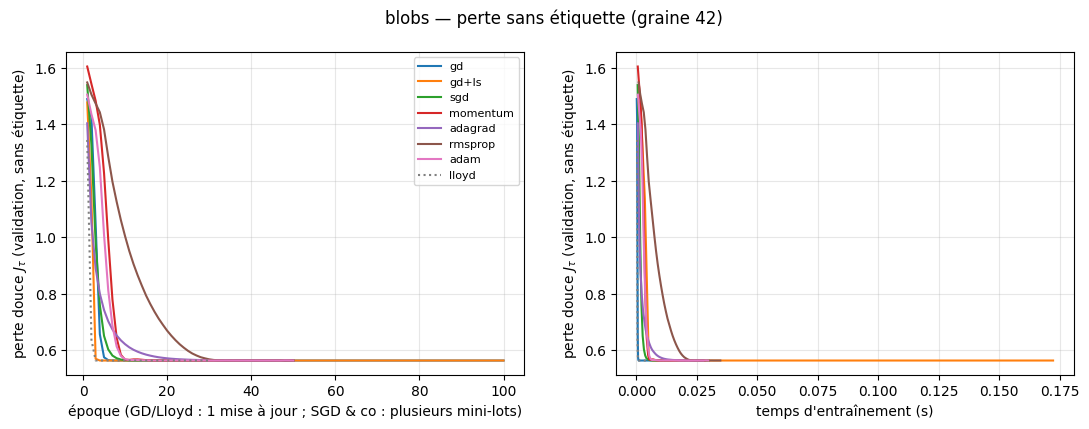

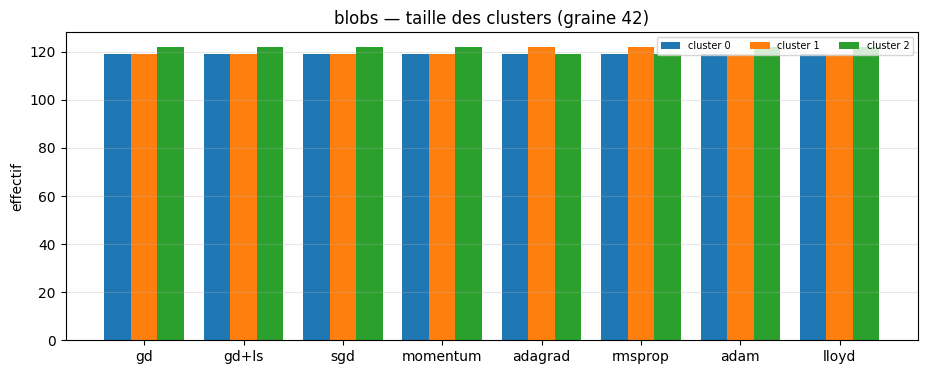

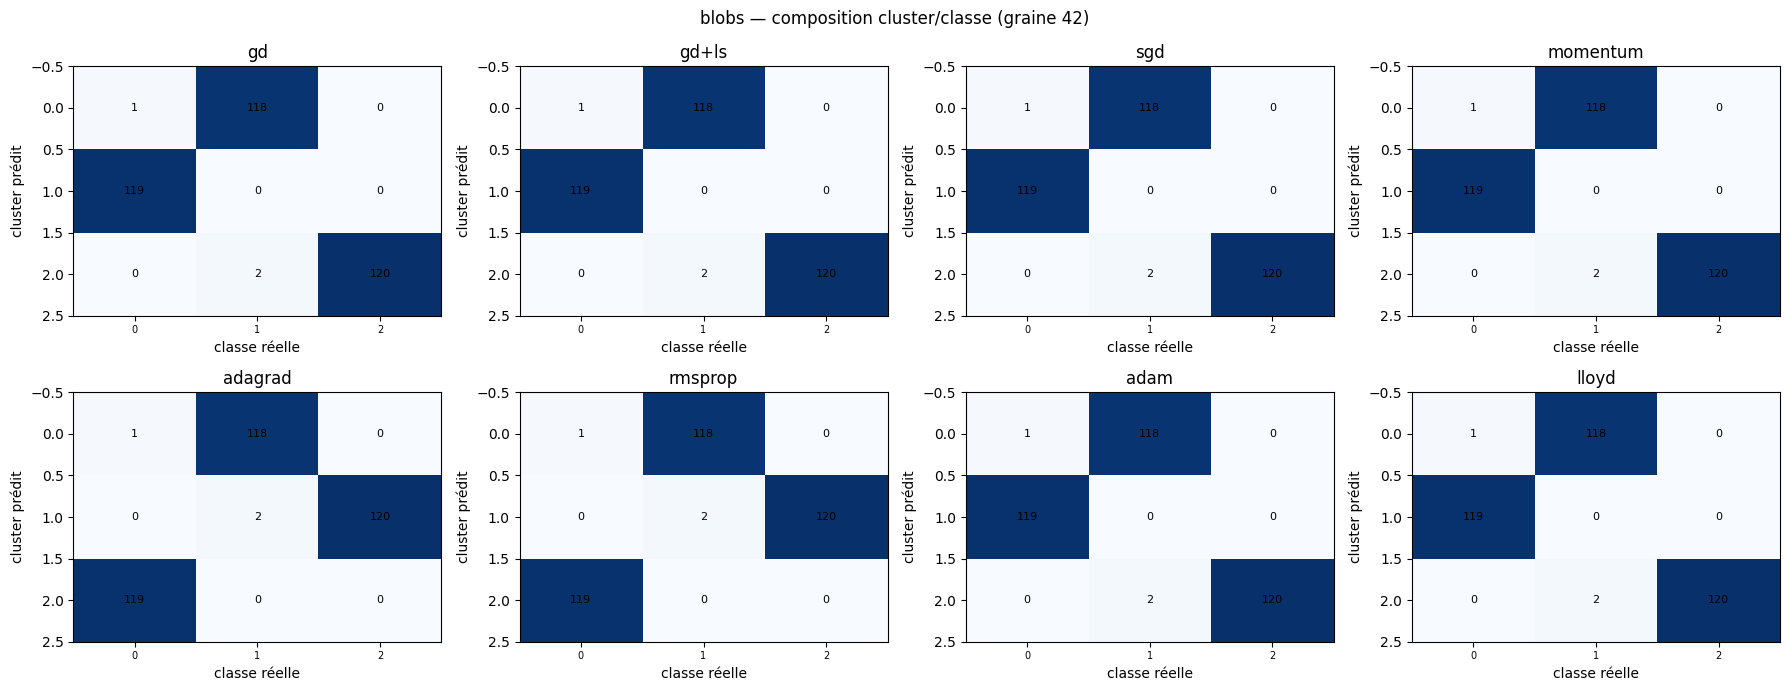

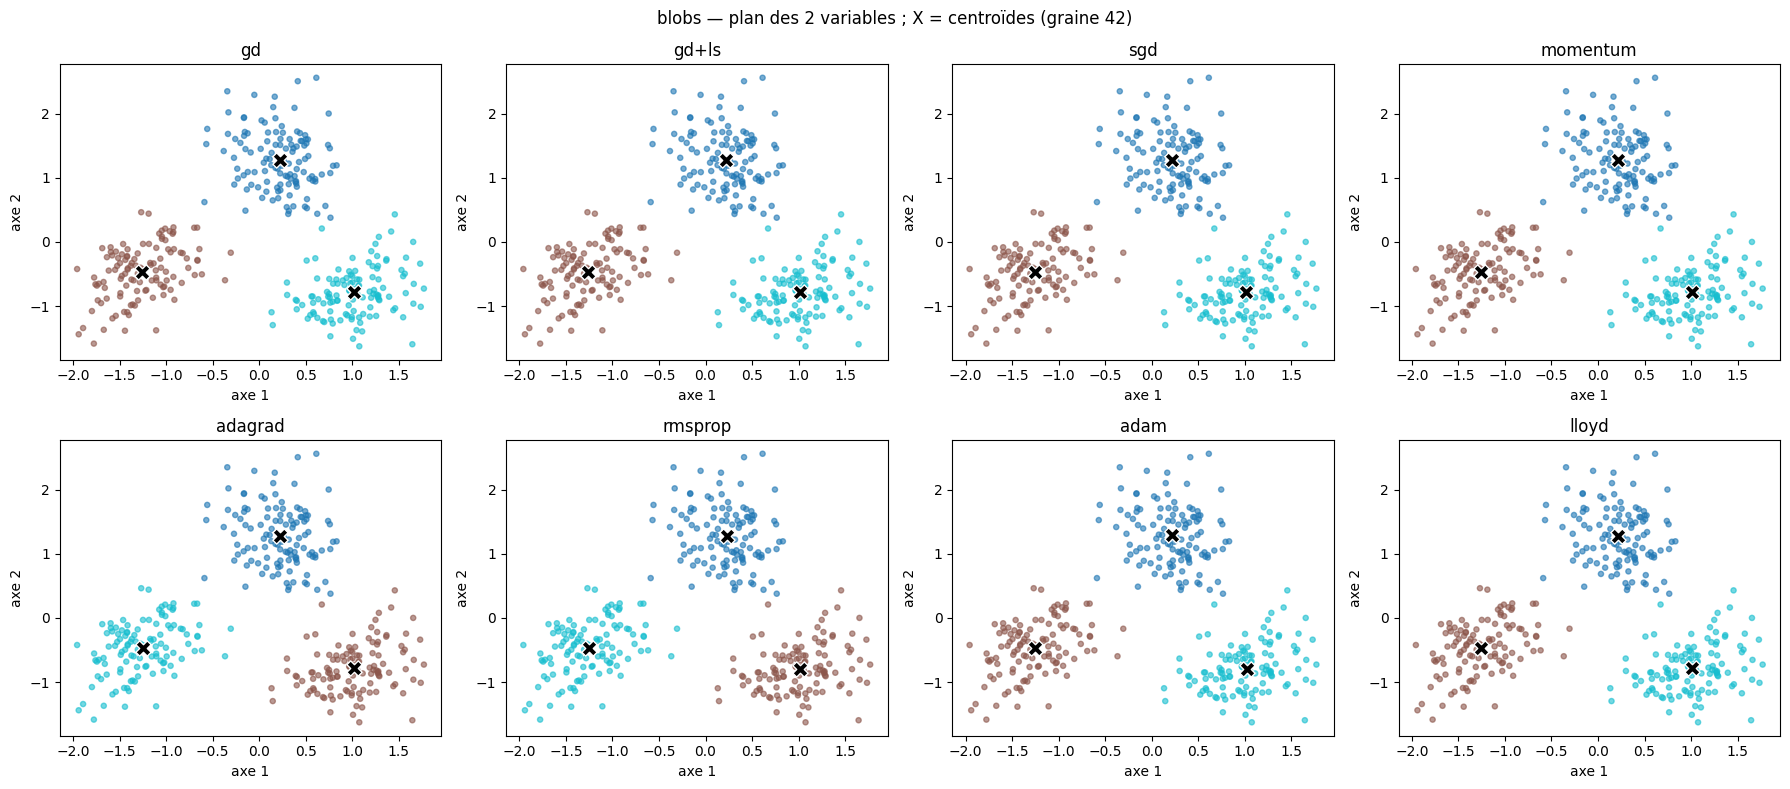

wine: n=178, d=13, classes de référence=3

===== WINE | K=3 | tau=0.25 | n_train=178 | n_eval=178 =====
  gd        eta*=0.3
  gd+ls     eta*=0.3
  sgd       eta*=0.1
  momentum  eta*=0.01
  adagrad   eta*=0.3
  rmsprop   eta*=0.03
  adam      eta*=0.03


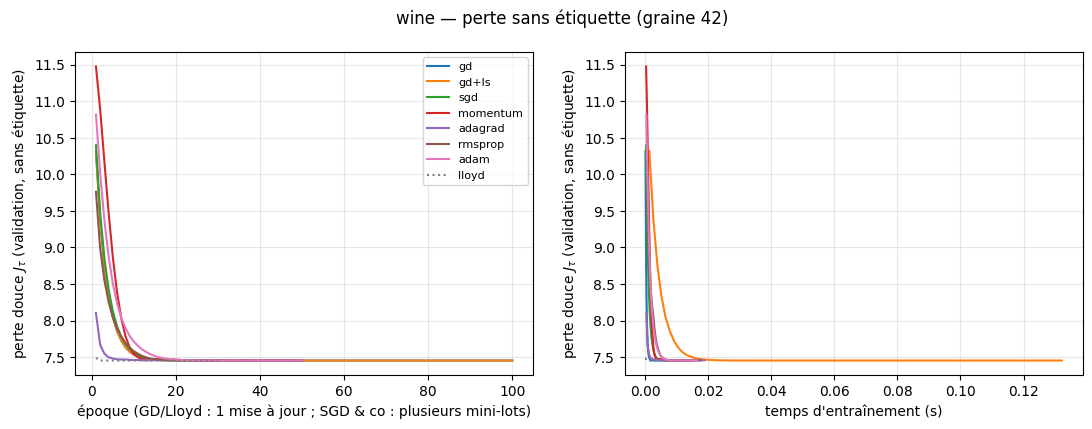

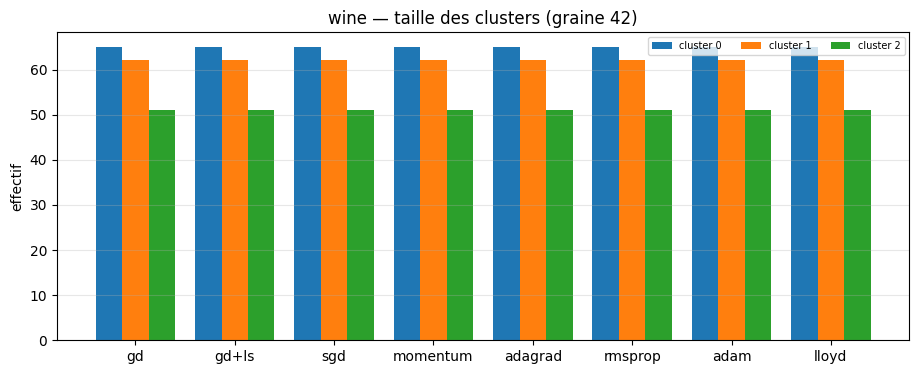

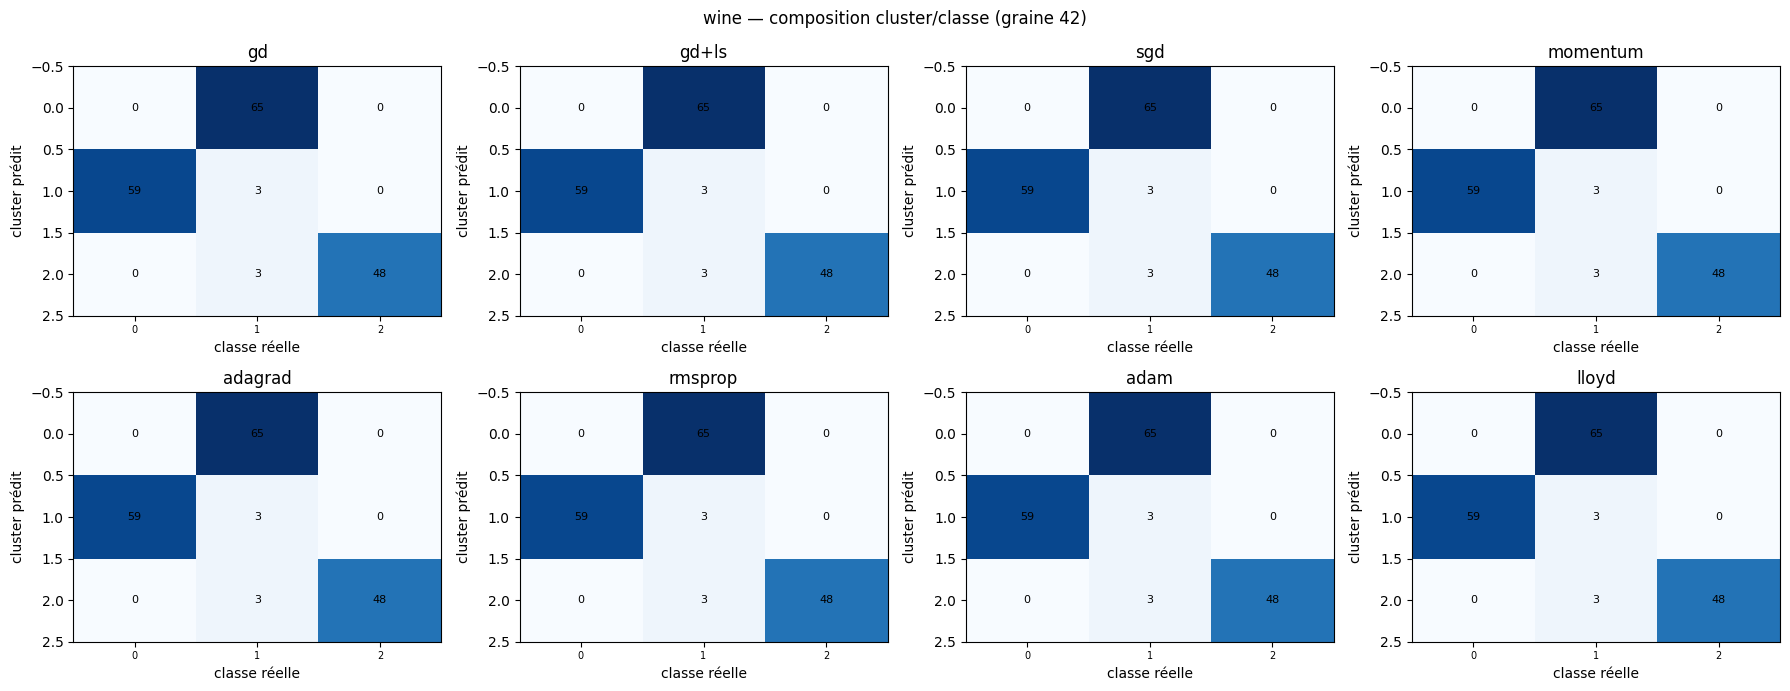

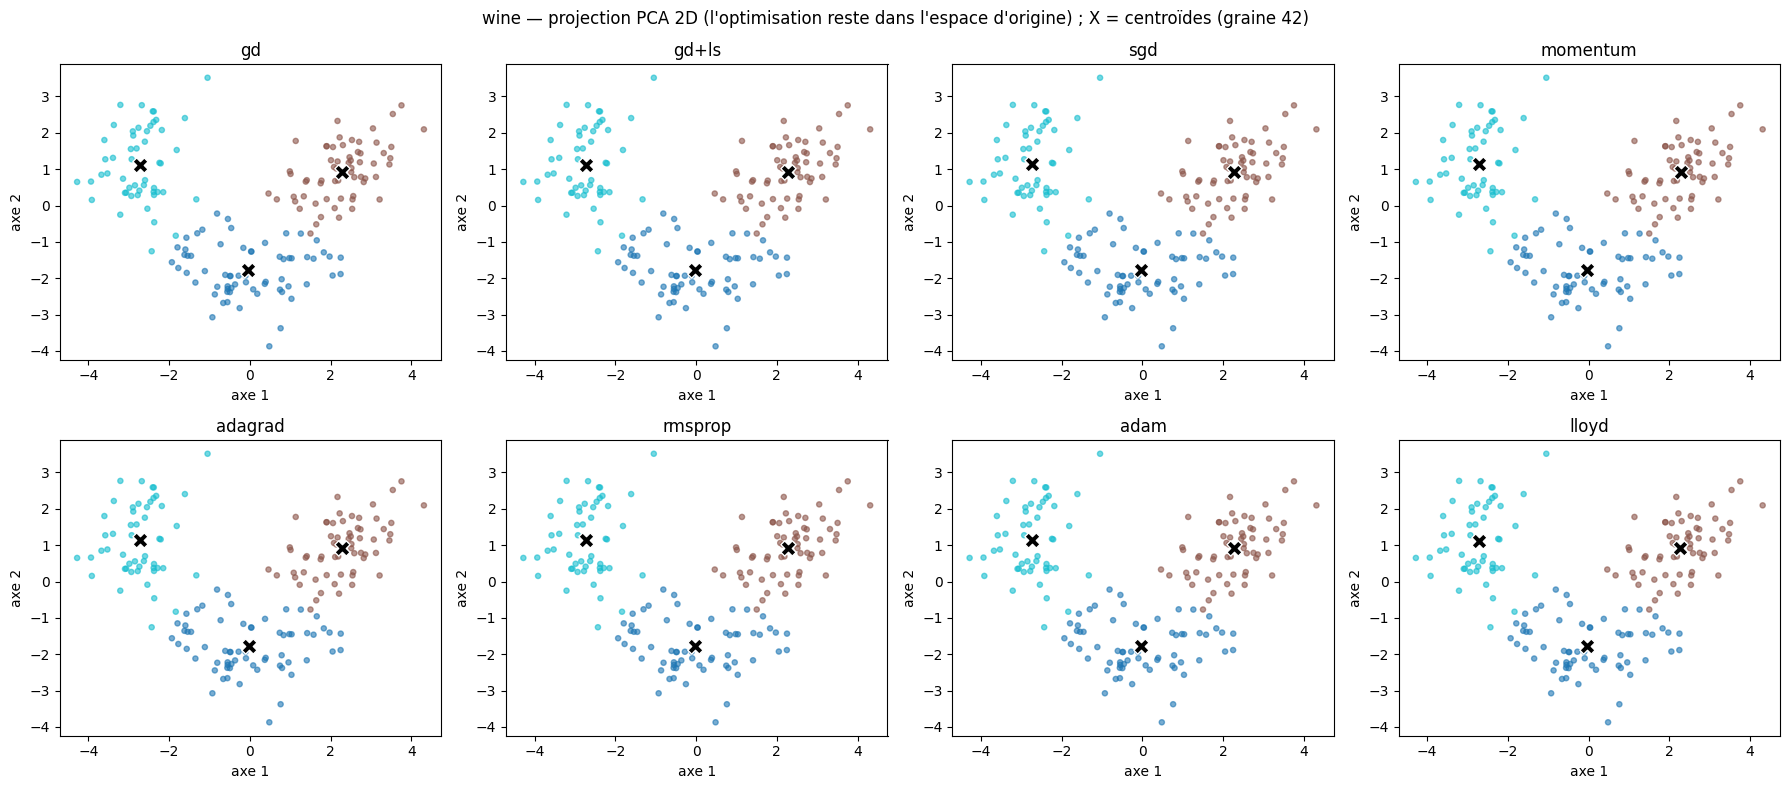

In [11]:

for key in RUN_CSV:
    X, y = load_tabular_all(key)
    run_dataset(key, X, X, X, y, K_BY_DATASET[key], TAU_BY_DATASET[key], CFG_CSV, is_image=False)

fashion_mnist_50k_10k_10k.npz absent -> tentative de reconstruction via tensorflow.keras.datasets ...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
NPZ reconstruit : data/fashion_mnist_50k_10k_10k.npz
fashion: train=(50000, 784), val=(10000, 784), test=(10000, 784), pixels in [0.00, 1.00]

===== FASHION | K=10 | tau=5.0 | n_train=50000 | n_eval=10000 =====
  gd        eta*=3.0 (borne de la grille !)
  gd+ls     eta*=3.0 (borne de la grille !)
  sgd       eta*=3.0 (borne de la grille !)
  momentum  eta*=0.3
  adagrad   eta*=0.1
  rmsprop   eta*=0.01
  adam      eta*=0.01


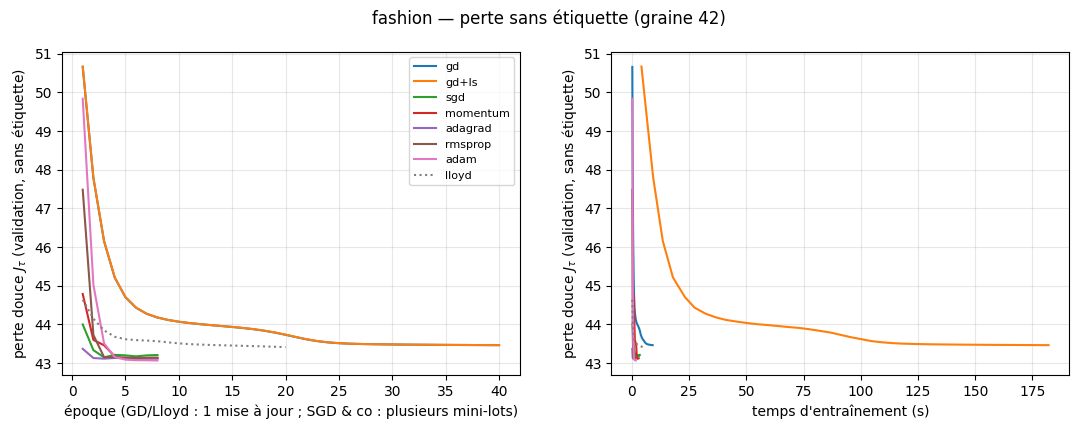

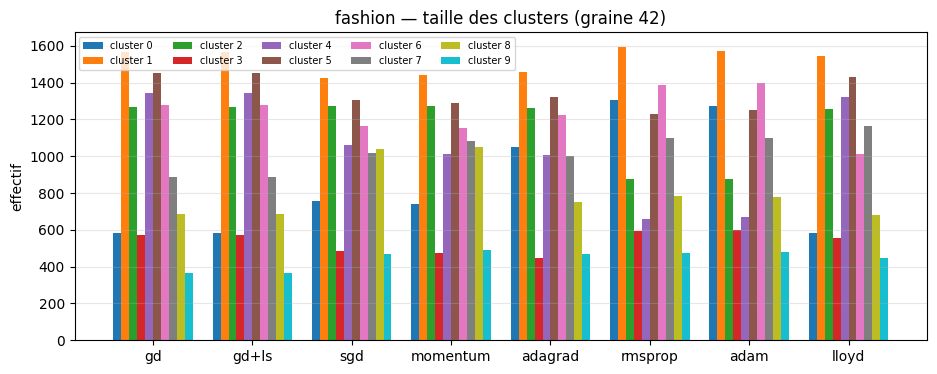

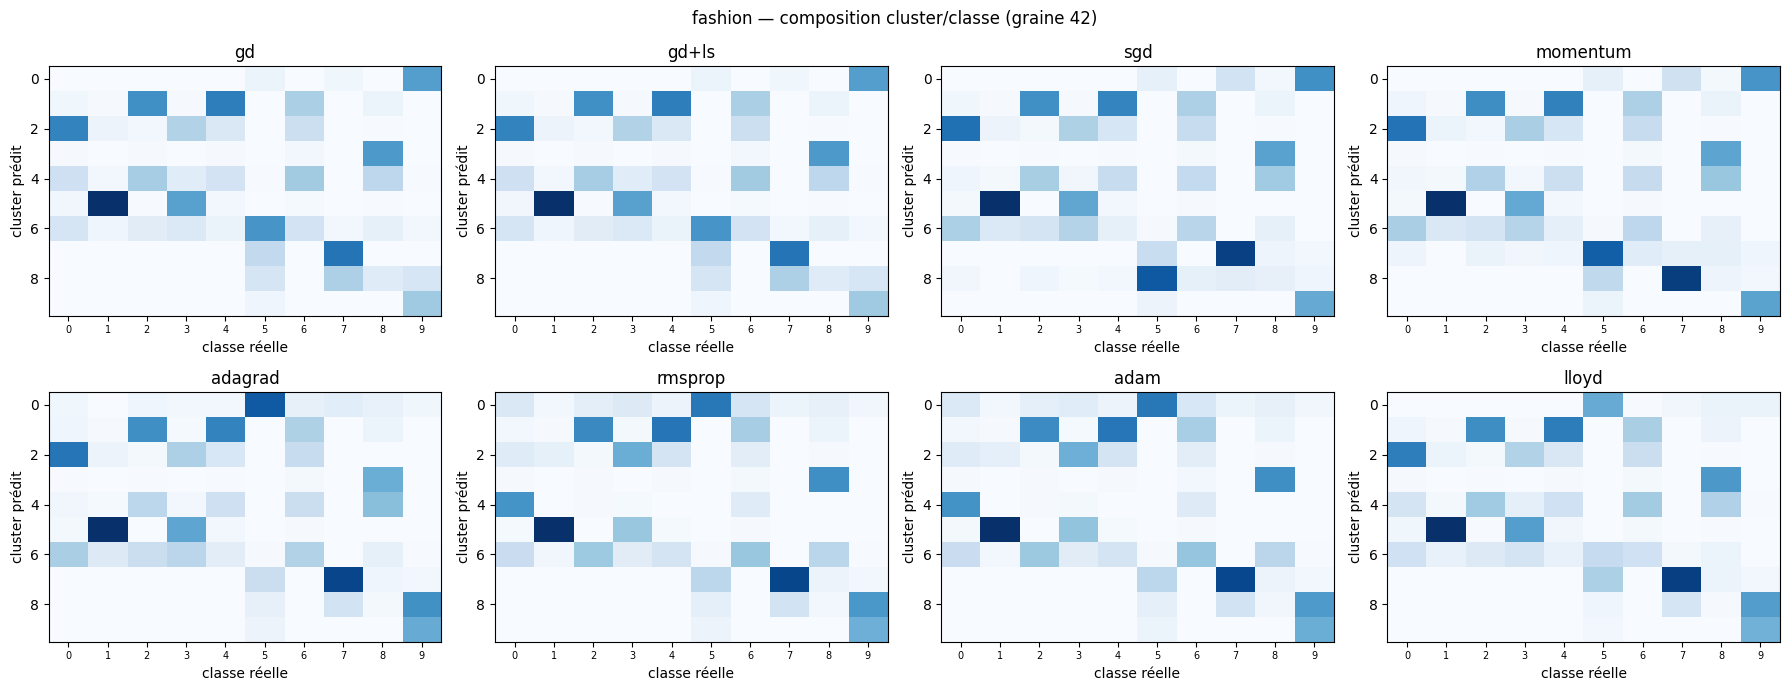

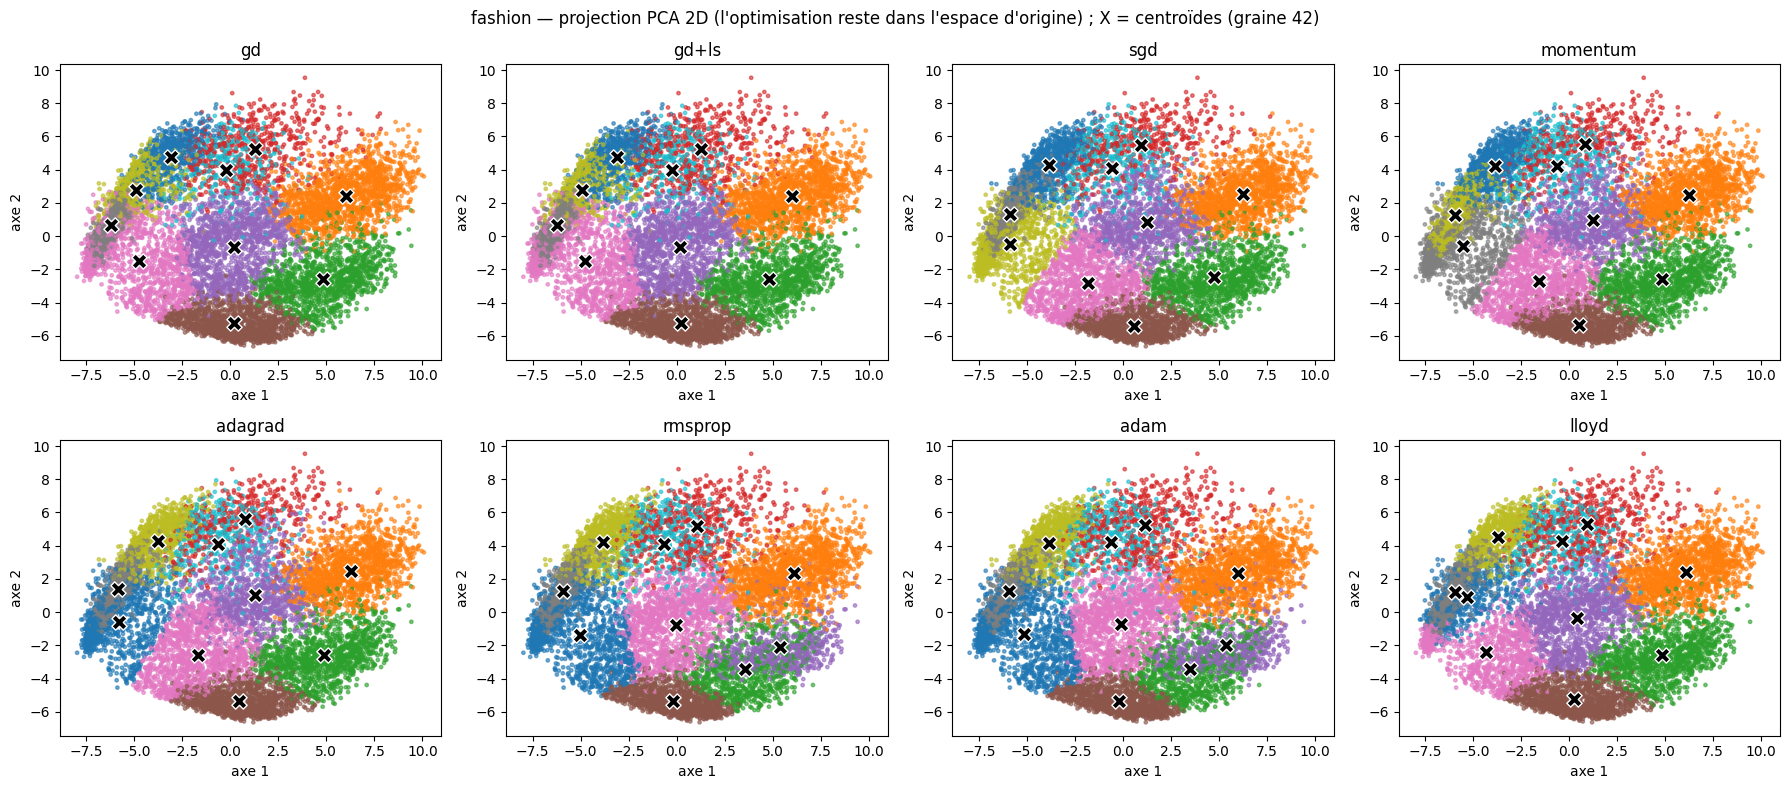

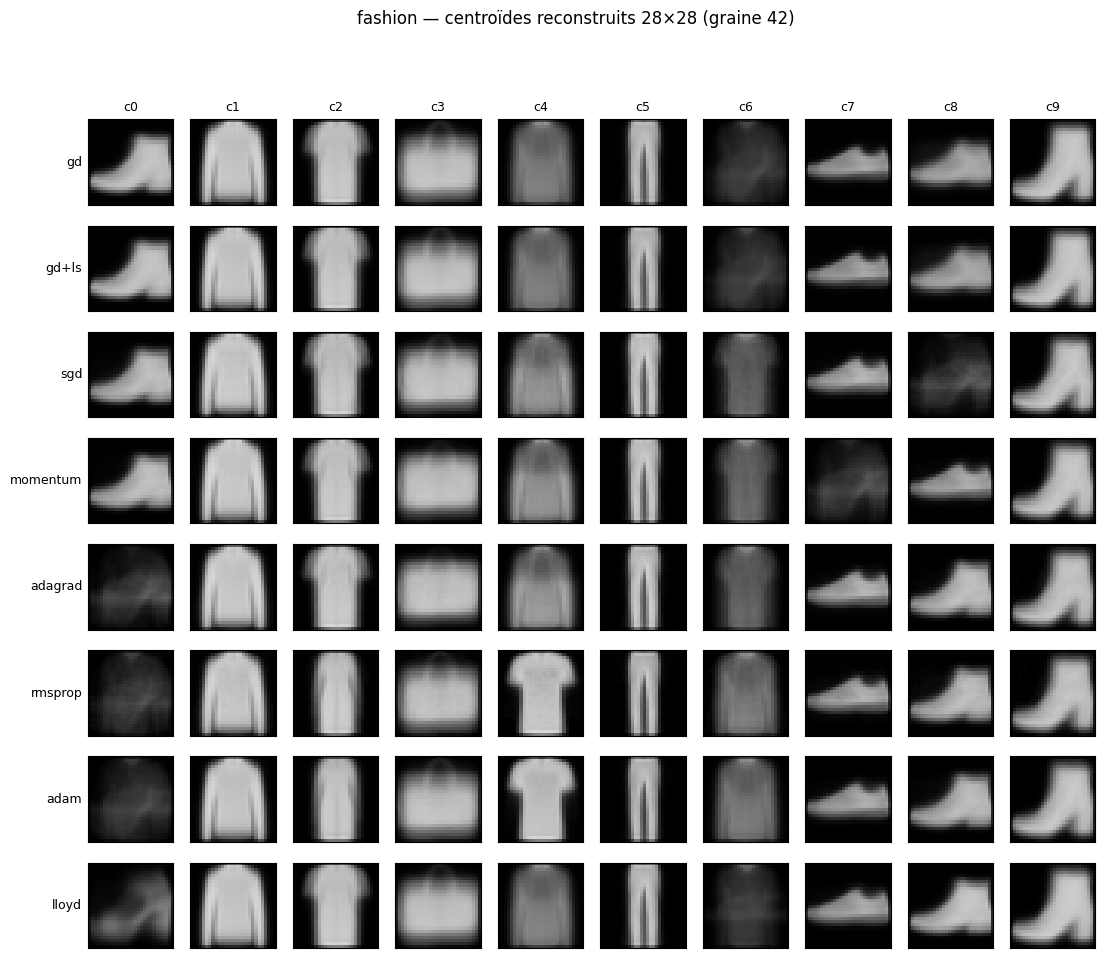

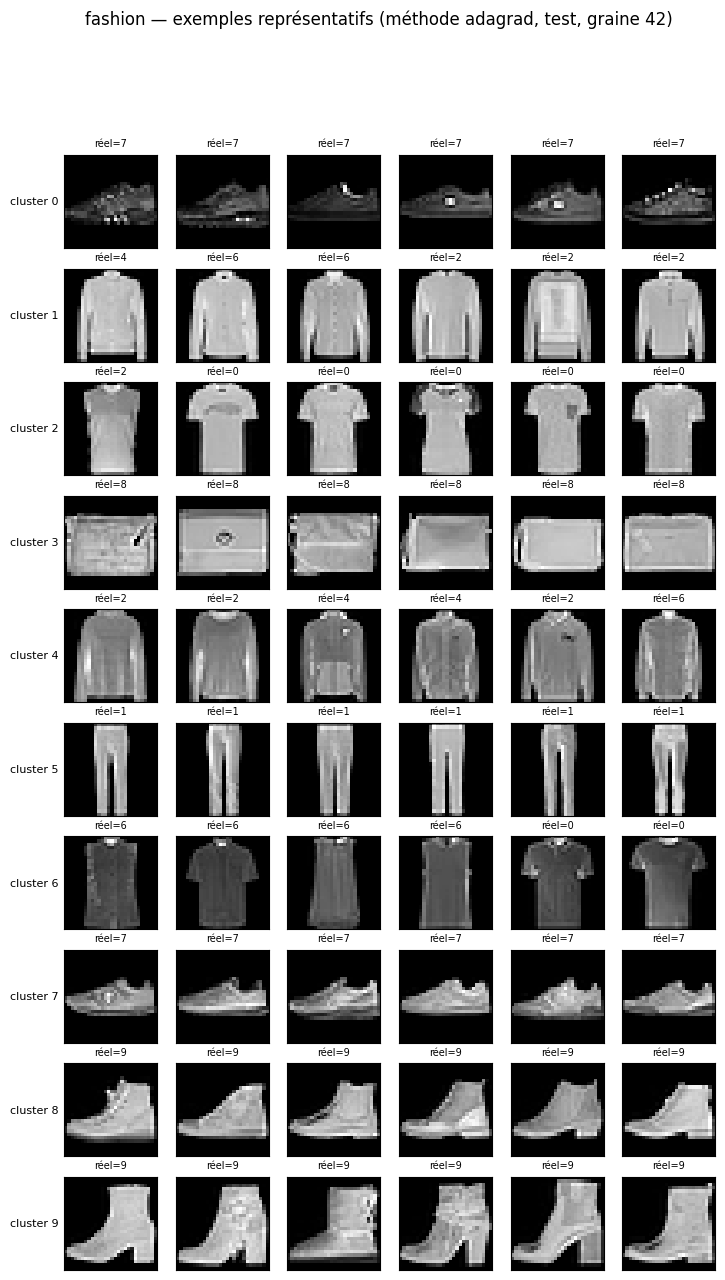

mnist_50k_10k_10k.npz absent -> tentative de reconstruction via tensorflow.keras.datasets ...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
NPZ reconstruit : data/mnist_50k_10k_10k.npz
mnist: train=(50000, 784), val=(10000, 784), test=(10000, 784), pixels in [0.00, 1.00]

===== MNIST | K=10 | tau=5.0 | n_train=50000 | n_eval=10000 =====
  gd        eta*=3.0 (borne de la grille !)
  gd+ls     eta*=3.0 (borne de la grille !)


In [ ]:

for key in RUN_IMAGES:
    D = load_images_npz(key)
    if D is None:
        continue
    run_dataset(key, D["train"], D["val"], D["test"], D["y_test"],
                K_BY_DATASET[key], TAU_BY_DATASET[key], CFG_IMG, is_image=True)

In [15]:

def fmt(col, nd=4, na_reason="N/A"):
    v = col.dropna().to_numpy(dtype=float)
    return na_reason if len(v) == 0 else f"{v.mean():.{nd}f} ± {v.std():.{nd}f}"

raw_df = pd.DataFrame(RAW)
raw_df.to_csv(OUT_DIR / "results_raw.csv", index=False)

rows = []
for (ds, m), g in raw_df.groupby(["dataset", "method"], sort=False):
    rows.append({
        "dataset": ds, "méthode": m, "eta": g["eta"].iloc[0], "graines": len(g),
        "J_tau": fmt(g["J_tau"]), "inertie moy.": fmt(g["inertia_mean"]),
        "clusters non vides": fmt(g["n_clusters"], 1),
        "silhouette": fmt(g["silhouette"], 4, "N/A (< 2 clusters non vides)"),
        "ARI": fmt(g["ari"]), "NMI": fmt(g["nmi"]),
        "meilleure époque": fmt(g["best_epoch"], 1), "mises à jour": fmt(g["n_updates"], 0),
        "appels gradient": fmt(g["n_grad"], 0), "appels perte": fmt(g["n_loss"], 0),
        "temps (s)": fmt(g["train_time_s"], 3),
    })
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "results_summary.csv", index=False)

pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for ds in summary["dataset"].unique():
    print(f"\n### {ds.upper()}  (J_tau, inertie, silhouette : sans étiquette ; ARI/NMI : évaluation externe finale)")
    display(summary[summary["dataset"] == ds].drop(columns="dataset").reset_index(drop=True))
print("\nFichiers écrits dans", OUT_DIR.resolve())


### BLOBS  (J_tau, inertie, silhouette : sans étiquette ; ARI/NMI : évaluation externe finale)


,méthode,eta,graines,J_tau,inertie moy.,clusters non vides,silhouette,ARI,NMI,meilleure époque,mises à jour,appels gradient,appels perte,temps (s)
0,gd,1.00,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,30.3 ± 2.6,100 ± 0,100 ± 0,0 ± 0,0.015 ± 0.001
1,gd+ls,3.00,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,32.3 ± 6.8,100 ± 0,100 ± 0,1400 ± 0,0.169 ± 0.003
2,sgd,0.10,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,28.7 ± 9.4,300 ± 0,300 ± 0,0 ± 0,0.029 ± 0.002
3,momentum,0.01,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,37.7 ± 7.6,300 ± 0,300 ± 0,0 ± 0,0.027 ± 0.001
4,adagrad,0.10,3,0.5645 ± 0.0003,0.2905 ± 0.0003,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,48.3 ± 1.7,300 ± 0,300 ± 0,0 ± 0,0.033 ± 0.004
5,rmsprop,0.01,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,42.0 ± 5.1,300 ± 0,300 ± 0,0 ± 0,0.031 ± 0.003
6,adam,0.03,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,34.3 ± 3.3,300 ± 0,300 ± 0,0 ± 0,0.035 ± 0.005
7,lloyd,NaN,3,0.5643 ± 0.0000,0.2903 ± 0.0000,3.0 ± 0.0,0.6793 ± 0.0000,0.9751 ± 0.0000,0.9596 ± 0.0000,30.0 ± 0.0,30 ± 0,0 ± 0,0 ± 0,0.005 ± 0.000



### WINE  (J_tau, inertie, silhouette : sans étiquette ; ARI/NMI : évaluation externe finale)


,méthode,eta,graines,J_tau,inertie moy.,clusters non vides,silhouette,ARI,NMI,meilleure époque,mises à jour,appels gradient,appels perte,temps (s)
0,gd,0.30,3,7.4539 ± 0.0000,7.1794 ± 0.0000,3.0 ± 0.0,0.2849 ± 0.0000,0.8975 ± 0.0000,0.8759 ± 0.0000,98.3 ± 2.4,100 ± 0,100 ± 0,0 ± 0,0.011 ± 0.000
1,gd+ls,0.30,3,7.4539 ± 0.0000,7.1794 ± 0.0000,3.0 ± 0.0,0.2849 ± 0.0000,0.8975 ± 0.0000,0.8759 ± 0.0000,98.7 ± 1.9,100 ± 0,100 ± 0,1400 ± 0,0.135 ± 0.002
2,sgd,0.10,3,7.4779 ± 0.0336,7.2040 ± 0.0346,3.0 ± 0.0,0.2827 ± 0.0031,0.8658 ± 0.0448,0.8422 ± 0.0476,46.0 ± 3.7,150 ± 0,150 ± 0,0 ± 0,0.016 ± 0.002
3,momentum,0.01,3,7.4782 ± 0.0341,7.2048 ± 0.0357,3.0 ± 0.0,0.2831 ± 0.0025,0.8712 ± 0.0372,0.8477 ± 0.0399,48.7 ± 1.9,150 ± 0,150 ± 0,0 ± 0,0.017 ± 0.002
4,adagrad,0.30,3,7.4551 ± 0.0002,7.1805 ± 0.0002,3.0 ± 0.0,0.2849 ± 0.0000,0.8975 ± 0.0000,0.8759 ± 0.0000,45.3 ± 3.7,150 ± 0,150 ± 0,0 ± 0,0.019 ± 0.000
5,rmsprop,0.03,3,7.4555 ± 0.0001,7.1809 ± 0.0002,3.0 ± 0.0,0.2849 ± 0.0000,0.8975 ± 0.0000,0.8759 ± 0.0000,43.7 ± 4.5,150 ± 0,150 ± 0,0 ± 0,0.016 ± 0.001
6,adam,0.03,3,7.4545 ± 0.0002,7.1800 ± 0.0002,3.0 ± 0.0,0.2849 ± 0.0000,0.8975 ± 0.0000,0.8759 ± 0.0000,47.3 ± 3.1,150 ± 0,150 ± 0,0 ± 0,0.017 ± 0.000
7,lloyd,NaN,3,7.4631 ± 0.0100,7.1894 ± 0.0111,3.0 ± 0.0,0.2838 ± 0.0023,0.8860 ± 0.0294,0.8716 ± 0.0191,30.0 ± 0.0,30 ± 0,0 ± 0,0 ± 0,0.004 ± 0.000



### FASHION  (J_tau, inertie, silhouette : sans étiquette ; ARI/NMI : évaluation externe finale)


,méthode,eta,graines,J_tau,inertie moy.,clusters non vides,silhouette,ARI,NMI,meilleure époque,mises à jour,appels gradient,appels perte,temps (s)
0,gd,3.00,3,43.1235 ± 0.2755,32.2439 ± 0.3395,10.0 ± 0.0,0.1393 ± 0.0105,0.3459 ± 0.0222,0.4992 ± 0.0125,40.0 ± 0.0,40 ± 0,40 ± 0,0 ± 0,9.538 ± 0.301
1,gd+ls,3.00,3,43.1238 ± 0.2753,32.2442 ± 0.3393,10.0 ± 0.0,0.1393 ± 0.0105,0.3459 ± 0.0222,0.4992 ± 0.0125,40.0 ± 0.0,40 ± 0,40 ± 0,560 ± 0,182.745 ± 0.509
2,sgd,3.00,3,42.8918 ± 0.0612,31.9843 ± 0.1054,10.0 ± 0.0,0.1443 ± 0.0066,0.3551 ± 0.0181,0.5076 ± 0.0093,3.7 ± 0.9,200 ± 0,200 ± 0,0 ± 0,2.276 ± 0.870
3,momentum,0.30,3,43.1443 ± 0.4812,32.2251 ± 0.4734,9.7 ± 0.5,0.1457 ± 0.0066,0.3368 ± 0.0078,0.4960 ± 0.0111,5.7 ± 0.5,200 ± 0,200 ± 0,0 ± 0,2.672 ± 0.235
4,adagrad,0.10,3,42.8583 ± 0.0895,31.9658 ± 0.1407,10.0 ± 0.0,0.1415 ± 0.0083,0.3422 ± 0.0040,0.5002 ± 0.0080,6.7 ± 0.9,200 ± 0,200 ± 0,0 ± 0,1.748 ± 0.029
5,rmsprop,0.01,3,42.9409 ± 0.1177,32.0345 ± 0.1545,10.0 ± 0.0,0.1417 ± 0.0084,0.3456 ± 0.0024,0.5036 ± 0.0065,6.7 ± 0.9,200 ± 0,200 ± 0,0 ± 0,1.721 ± 0.055
6,adam,0.01,3,42.8835 ± 0.1154,31.9767 ± 0.1580,10.0 ± 0.0,0.1421 ± 0.0082,0.3462 ± 0.0042,0.5039 ± 0.0080,8.0 ± 0.0,200 ± 0,200 ± 0,0 ± 0,2.299 ± 0.780
7,lloyd,NaN,3,42.9717 ± 0.1610,32.0455 ± 0.2043,10.0 ± 0.0,0.1436 ± 0.0077,0.3395 ± 0.0135,0.5004 ± 0.0173,20.0 ± 0.0,20 ± 0,0 ± 0,0 ± 0,4.421 ± 0.381



### MNIST  (J_tau, inertie, silhouette : sans étiquette ; ARI/NMI : évaluation externe finale)


,méthode,eta,graines,J_tau,inertie moy.,clusters non vides,silhouette,ARI,NMI,meilleure époque,mises à jour,appels gradient,appels perte,temps (s)
0,gd,3.00,3,49.5797 ± 0.2623,39.9059 ± 0.2010,9.7 ± 0.5,0.0538 ± 0.0050,0.3306 ± 0.0261,0.4572 ± 0.0188,40.0 ± 0.0,40 ± 0,40 ± 0,0 ± 0,9.927 ± 0.555
1,gd+ls,3.00,3,49.4286 ± 0.1962,39.8150 ± 0.1118,10.0 ± 0.0,0.0541 ± 0.0097,0.3298 ± 0.0495,0.4543 ± 0.0371,40.0 ± 0.0,40 ± 0,40 ± 0,560 ± 0,182.749 ± 1.014
2,sgd,3.00,3,49.3890 ± 0.3602,39.6034 ± 0.3153,9.7 ± 0.5,0.0539 ± 0.0009,0.3588 ± 0.0026,0.4801 ± 0.0021,7.0 ± 0.8,200 ± 0,200 ± 0,0 ± 0,2.064 ± 0.630
3,momentum,0.10,3,49.2788 ± 0.0478,39.7276 ± 0.0812,10.0 ± 0.0,0.0533 ± 0.0066,0.3392 ± 0.0322,0.4608 ± 0.0194,7.7 ± 0.5,200 ± 0,200 ± 0,0 ± 0,1.681 ± 0.020
4,adagrad,0.30,3,49.1803 ± 0.0208,39.4381 ± 0.0490,10.0 ± 0.0,0.0535 ± 0.0003,0.3540 ± 0.0034,0.4761 ± 0.0026,7.3 ± 0.9,200 ± 0,200 ± 0,0 ± 0,2.874 ± 0.817
5,rmsprop,0.01,3,49.1851 ± 0.0662,39.4341 ± 0.0573,10.0 ± 0.0,0.0543 ± 0.0013,0.3571 ± 0.0031,0.4800 ± 0.0054,7.3 ± 0.9,200 ± 0,200 ± 0,0 ± 0,2.310 ± 0.839
6,adam,0.01,3,49.2694 ± 0.0182,39.6402 ± 0.0929,10.0 ± 0.0,0.0541 ± 0.0042,0.3572 ± 0.0345,0.4726 ± 0.0226,8.0 ± 0.0,200 ± 0,200 ± 0,0 ± 0,2.034 ± 0.582
7,lloyd,NaN,3,49.4323 ± 0.0678,39.4009 ± 0.1262,10.0 ± 0.0,0.0569 ± 0.0071,0.3604 ± 0.0301,0.4831 ± 0.0182,20.0 ± 0.0,20 ± 0,0 ± 0,0 ± 0,4.349 ± 0.319



Fichiers écrits dans /content/results


In [16]:
import shutil
from pathlib import Path

DEST = Path("resultat exercice 3")
if DEST.exists():
    shutil.rmtree(DEST)
shutil.copytree(OUT_DIR, DEST)          # OUT_DIR = "results" (figures PNG + CSV)

zip_path = shutil.make_archive("resultat exercice 3", "zip", root_dir=".", base_dir=str(DEST))

print("Contenu du dossier :")
for f in sorted(DEST.iterdir()):
    print("  -", f.name)
print("Archive créée :", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Hors Colab : le dossier se trouve ici ->", DEST.resolve())

Contenu du dossier :
  - blobs_composition.png
  - blobs_curves.png
  - blobs_scatter.png
  - blobs_sizes.png
  - fashion_centroids.png
  - fashion_composition.png
  - fashion_curves.png
  - fashion_examples.png
  - fashion_scatter.png
  - fashion_sizes.png
  - mnist_centroids.png
  - mnist_composition.png
  - mnist_curves.png
  - mnist_examples.png
  - mnist_scatter.png
  - mnist_sizes.png
  - results_raw.csv
  - results_summary.csv
  - wine_composition.png
  - wine_curves.png
  - wine_scatter.png
  - wine_sizes.png
Archive créée : /content/resultat exercice 3.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>